<a href="https://colab.research.google.com/github/Deltacp1/dados-vendas/blob/main/An%C3%A1lise_dados_vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving itens_vendidos.csv to itens_vendidos (1).csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv('itens_vendidos.csv')

print(df.shape)
print(df.columns.tolist())
df.dtypes

(59959, 8)
['cod_venda', 'cod_produto', 'descricao', 'categoria', 'unidade', 'quantidade', 'valor_unitario', 'valor_total_item']


,0
cod_venda,int64
cod_produto,object
descricao,object
categoria,object
unidade,object
quantidade,float64
valor_unitario,float64
valor_total_item,float64


In [37]:
#df.head()
#df.tail(3)
df.sample(3)

,cod_venda,cod_produto,descricao,categoria,unidade,quantidade,valor_unitario,valor_total_item
22769,11872,CAR005,Coxao Duro,Carnes,KG,1.411,34.53,48.72
59306,15017,DOC006,Pacoca Amor 20un,Doces e Snacks,UN,2.000,9.34,18.68
11718,10925,MER002,Biscoito Recheado Oreo,Mercearia,UN,1.000,5.52,5.52


In [33]:
df.describe().round(2)

,cod_venda,quantidade,valor_unitario,valor_total_item
count,59959.00,59959.00,59959.00,59959.00
mean,12511.17,1.63,11.49,16.82
std,1475.73,0.81,10.73,16.11
min,10001.00,0.30,1.50,1.46
25%,11222.00,1.00,5.11,7.36
50%,12549.00,1.30,7.54,11.99
75%,13785.00,2.00,12.61,19.74
max,15084.00,5.00,74.83,173.48


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59959 entries, 0 to 59958
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cod_venda         59959 non-null  int64  
 1   cod_produto       59959 non-null  object 
 2   descricao         59959 non-null  object 
 3   categoria         59959 non-null  object 
 4   unidade           59959 non-null  object 
 5   quantidade        59959 non-null  float64
 6   valor_unitario    59959 non-null  float64
 7   valor_total_item  59959 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 3.7+ MB


In [14]:
df.isnull().sum()

,0
cod_venda,0
cod_produto,0
descricao,0
categoria,0
unidade,0
quantidade,0
valor_unitario,0
valor_total_item,0


In [15]:
df['categoria'].value_counts()

,count
categoria,
Cesta Basica,9507
Padaria e Laticinios,7027
Bebidas,6782
Hortifruti,6637
Carnes,6377
Doces e Snacks,6141
Higiene,6030
Mercearia,6008
Limpeza,5450


In [46]:
#categoria bebidas
carnes = df[df['categoria'] == 'Carnes']
print(carnes.shape)

#itens considerados caros
caros = df[df['valor_total_item'] > 100]
print(caros.shape)

(6377, 8)
(248, 8)


In [48]:
fat = df.groupby('categoria')['valor_total_item'].sum()
fat.sort_values(ascending=True).round(2)
fat.sort_values(ascending=False).round(2)

,valor_total_item
categoria,
Carnes,291430.47
Cesta Basica,142809.13
Padaria e Laticinios,130308.61
Higiene,88819.03
Mercearia,76605.29
Bebidas,71406.21
Doces e Snacks,70608.76
Hortifruti,69821.46
Limpeza,66692.56


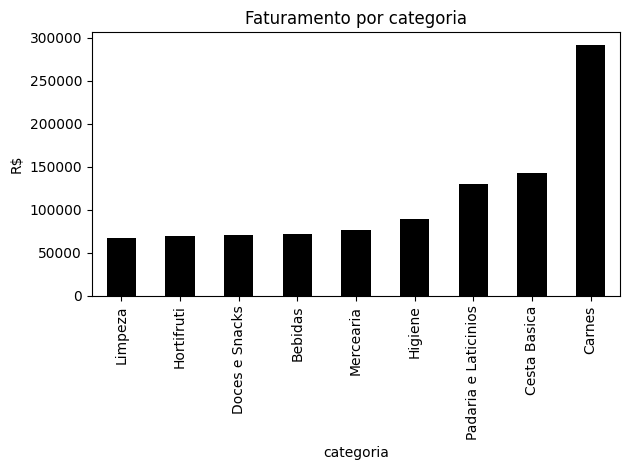

In [52]:
fat = df.groupby('categoria')['valor_total_item'].sum().sort_values()
fat.plot(kind='bar', color='#000000')
plt.title('Faturamento por categoria')
plt.ylabel('R$'); plt.tight_layout()
plt.show()


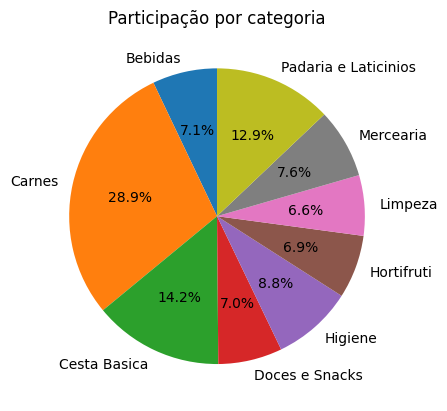

In [27]:
fat= df.groupby('categoria')['valor_total_item'].sum()
plt.pie(fat, labels= fat.index, autopct='%1.1f%%', startangle=90)
plt.title('Participação por categoria')

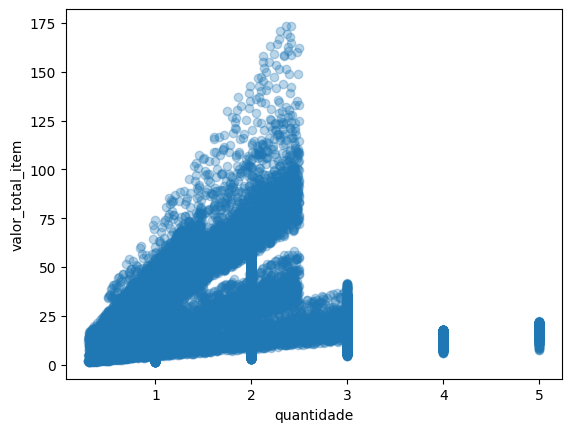

In [28]:
plt.scatter(df['quantidade'],
            df['valor_total_item'], alpha=0.3)
plt.xlabel('quantidade')
plt.ylabel('valor_total_item')
plt.show()
